# Del 0: Innledning  
# Romlig analyse av tilfluktsrom og befolkning i Agder  

## Bakgrunn  

Som en del av temaet *Totalforsvarets år* undersøker denne notebooken hvordan tilfluktsrom er geografisk distribuert i forhold til befolkningen i Agder.  
Tilgang til tilfluktsrom er en sentral del av sivil beredskap, og den romlige fordelingen av disse kan ha stor betydning for hvor godt befolkningen er beskyttet i en krisesituasjon.  

Ved å kombinere data om tilfluktsrom med befolkningsdata og geografiske analyser, er det mulig å identifisere områder med god eller svak dekning. Dette gir et mer nyansert bilde av beredskapssituasjonen enn å kun visualisere hvor tilfluktsrommene ligger.

## Problemstilling  

Analysen forsøker å besvare følgende spørsmål:  

1. Hvor ligger tilfluktsrommene i Agder?  
2. Hvordan er de geografisk fordelt i forhold til hvor befolkningen bor?  
3. Finnes det områder med høy befolkningstetthet som har svak tilgang til tilfluktsrom?  
4. Hvordan kan romlige analysemetoder brukes for å avdekke slike mønstre?  

## Planlagt analyse  

Notebooken dokumenterer en fullstendig romlig analyseprosess som inkluderer:  

- innlasting av flere geografiske datasett  
- filtrering av data til Agder  
- visualisering av tilfluktsrom og befolkningsdata  
- bufferanalyse rundt tilfluktsrom  
- overlay-analyse for å identifisere dekkede og ikke-dekkede områder  
- romlig aggregering av befolkning innenfor og utenfor dekning  
- rasteranalyse av terreng (helning og egnethet)  

Målet er å gå fra en enkel visualisering av data til en mer analytisk vurdering av geografisk dekning og beredskap.

## Datasett  

Analysen tar utgangspunkt i flere datasett:  

- tilfluktsrom (punktdata fra database)  
- fylkesgrenser (polygondata fra database)  
- befolkningsdata (rutenett eller administrative enheter)  
- terrengdata (DEM raster)  

Datasettet for tilfluktsrom dekker hele Norge og filtreres til Agder ved hjelp av romlige operasjoner.  
Befolkningsdata brukes for å analysere hvor mennesker faktisk bor, og gjør det mulig å vurdere dekning i et samfunnsperspektiv.

## Verktøy  

Følgende Python-biblioteker benyttes i analysen:  

- pandas  
- geopandas  
- matplotlib  
- rasterio  
- shapely  
- duckdb  

## Del 1: Oppsett og import av biblioteker  

I denne delen importeres nødvendige biblioteker som brukes i analysen.  
Formålet er å etablere et teknisk og analytisk grunnlag for videre arbeid i notebooken.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape
import duckdb

# Del 2: Innlasting av data

I denne delen lastes de første datasettene som skal brukes i analysen inn i notebooken.

Målet er å etablere et tydelig datagrunnlag før videre filtrering, visualisering og romlige analyser.  
Ettersom datasettet med tilfluktsrom allerede finnes i prosjektets PostgreSQL/PostGIS-database, brukes databasen som primær datakilde i denne delen.

Oppgaven krever at minst to ulike datasett leses inn. I denne analysen brukes foreløpig:

- fylkesgrenser fra tabellen `fylker`
- tilfluktsrom fra tabellen `shelters`

Begge datasettene hentes fra prosjektets database og avgrenses videre til området Agder.

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Last inn .env fra prosjektroten
load_dotenv(Path("..") / ".env")

database_url = os.getenv("DATABASE_URL")

print("Fant DATABASE_URL:", database_url is not None)
if database_url:
    print(database_url[:50] + "...")

Fant DATABASE_URL: True
postgresql://postgres.sttveigwszjfndfxvugo:58eyPPe...


## 2.1 Tilkobling til prosjektets database

I denne delen opprettes en forbindelse til prosjektets PostgreSQL/PostGIS-database ved hjelp av `DATABASE_URL` fra prosjektets `.env`-fil.

Dette er nødvendig fordi datasettet med tilfluktsrom ikke finnes som lokal fil i prosjektet, men er lagret i databasen.  
Ved å koble notebooken direkte til databasen kan analysen bruke de samme geografiske dataene som resten av prosjektet bygger på.

Først testes det at forbindelsen fungerer, før geografiske data hentes ut videre i analysen.


In [3]:
import sqlalchemy
from sqlalchemy import text

engine = sqlalchemy.create_engine(database_url)

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), current_user;"))
    for row in result:
        print("Database:", row[0])
        print("Bruker:", row[1])

Database: postgres
Bruker: postgres


For å kontrollere at de forventede datasettene finnes i databasen, hentes det deretter ut en oversikt over tabellene i `public`-schemaet.

In [4]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        ORDER BY table_name;
    """))
    
    tables = [row[0] for row in result]

print("Tabeller i public-schema:")
for table in tables:
    print("-", table)

Tabeller i public-schema:
- brannstasjoner
- fylker
- geography_columns
- geometry_columns
- shelters
- spatial_ref_sys


## 2.2 Undersøkelse av tabellstruktur

Før geografiske data leses inn, er det viktig å undersøke hvilke kolonner som finnes i de relevante databasetabellene.

Dette gjøres for å bekrefte hvilke attributter og geometri-kolonner som finnes i tabellene `fylker` og `shelters`.  
Ved å kontrollere tabellstrukturen først, unngår man feil i SQL-spørringer og får bedre forståelse av hvilke data som er tilgjengelige for videre analyse.

In [5]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT table_name, column_name, data_type
        FROM information_schema.columns
        WHERE table_schema = 'public'
          AND table_name IN ('fylker', 'shelters')
        ORDER BY table_name, ordinal_position;
    """))
    
    for row in result:
        print(row)

('fylker', 'id', 'integer')
('fylker', 'navn', 'character varying')
('fylker', 'geomfylke', 'USER-DEFINED')
('shelters', 'fid', 'integer')
('shelters', 'gml_id', 'character varying')
('shelters', 'lokalid', 'character varying')
('shelters', 'navnerom', 'character varying')
('shelters', 'versjonid', 'integer')
('shelters', 'datauttaksdato', 'timestamp with time zone')
('shelters', 'opphav', 'character varying')
('shelters', 'romnr', 'integer')
('shelters', 'plasser', 'integer')
('shelters', 'adresse', 'character varying')
('shelters', 'posisjon', 'USER-DEFINED')


## 2.3 Identifisering av riktig fylke

Før fylkesgrensen kan hentes ut, må riktig fylkes-ID identifiseres i databasen.

Dette gjøres ved å hente en oversikt over alle fylker i tabellen `fylker`.  
Ved å inspisere denne tabellen kan man finne hvilken ID som tilsvarer Agder.

Dette steget er viktig fordi videre analyser avhenger av at riktig geografisk område velges.  
Ved å eksplisitt kontrollere fylkes-ID unngås feil der analyser utføres på feil region.

In [20]:
sql_fylker = """
SELECT id, navn
FROM public.fylker
ORDER BY id
"""

df_fylker = pd.read_sql(sql_fylker, engine)
df_fylker

,id,navn
0,1,Vestland
1,2,Østfold
2,3,Finnmark
3,4,Rogaland
4,5,Agder
5,6,Trøndelag
6,7,Nordland
7,8,Møre og Romsdal
8,9,Buskerud
9,10,Vestfold


## 2.4 Innlasting av fylkesgrense for Agder

Når riktig fylkes-ID er identifisert (Agder = id 5), hentes fylkesgrensen fra databasen.

Geometrien representerer analyseområdet for resten av notebooken.  
Ved å lese inn fylket som et polygon kan det brukes til romlig filtrering, visualisering og videre analyser.    

In [7]:
sql_agder = """
SELECT
    id,
    navn,
    geomfylke
FROM public.fylker
WHERE id = 5
"""

gdf_agder = gpd.read_postgis(sql_agder, engine, geom_col="geomfylke")
gdf_agder

,id,navn,geomfylke
0,5,Agder,"POLYGON ((7.21467 59.67269, 7.21112 59.66901, ..."


## 2.5 Innlasting av tilfluktsrom i Agder

Etter at analyseområdet er definert, hentes alle registrerte tilfluktsrom som ligger innenfor Agder fra tabellen `shelters`.

Dette gjøres med en romlig SQL-spørring der funksjonen `ST_Within` brukes til å filtrere ut shelter-punkter som ligger innenfor fylkespolygonet til Agder.

Dette steget er viktig fordi analysen skal være avgrenset til ett studieområde.  
Ved å gjøre filtreringen direkte i databasen hentes bare relevante objekter inn i Python, noe som gjør videre arbeid mer effektivt og mer presist.

In [8]:
sql_shelters_agder = """
SELECT
    fid,
    romnr,
    plasser,
    adresse,
    navnerom,
    posisjon
FROM public.shelters
WHERE ST_Within(
    posisjon,
    (SELECT geomfylke FROM public.fylker WHERE id = 5)
)
"""

gdf_shelters = gpd.read_postgis(sql_shelters_agder, engine, geom_col="posisjon")
gdf_shelters.head()

,fid,romnr,plasser,adresse,navnerom,posisjon
0,47,1688,136,BANEHEIVEIEN,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.98237 58.14915)
1,48,1707,195,BYDALSVEIEN 19,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.92203 58.14805)
2,49,1740,65,FREDRIK FRANSSONSVEI 4,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (8.08398 58.183)
3,50,1755,235,GROSTØLVEIEN 4 E,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (8.03204 58.20018)
4,51,1756,500,GRÅGÅSVEIEN 43,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.93656 58.12147)


## 2.6 Kontroll av innleste datasett

Etter innlasting av både fylkesgrensen og tilfluktsrommene, kontrolleres datasettene for å sikre at de er korrekt strukturert.

Det undersøkes hvor mange objekter som er hentet, hvilke kolonner som finnes, og hvilket koordinatsystem dataene bruker.

Dette er nødvendig før videre analyse, siden romlige operasjoner krever gyldig geometri og riktig koordinatsystem.

In [9]:
print("Agder:")
print("Antall objekter:", len(gdf_agder))
print("CRS:", gdf_agder.crs)
print("Kolonner:", gdf_agder.columns.tolist())

print("\nShelters i Agder:")
print("Antall objekter:", len(gdf_shelters))
print("CRS:", gdf_shelters.crs)
print("Kolonner:", gdf_shelters.columns.tolist())

Agder:
Antall objekter: 1
CRS: EPSG:4326
Kolonner: ['id', 'navn', 'geomfylke']

Shelters i Agder:
Antall objekter: 65
CRS: EPSG:4326
Kolonner: ['fid', 'romnr', 'plasser', 'adresse', 'navnerom', 'posisjon']


## 2.7 Visualisering av studieområde og tilfluktsrom

For å kontrollere at dataene er riktig lest inn, visualiseres fylkesgrensen for Agder sammen med tilfluktsrommene.

Visualiseringen fungerer som en kvalitetssjekk av de romlige dataene, og gir en første forståelse av hvordan tilfluktsrommene er fordelt geografisk.

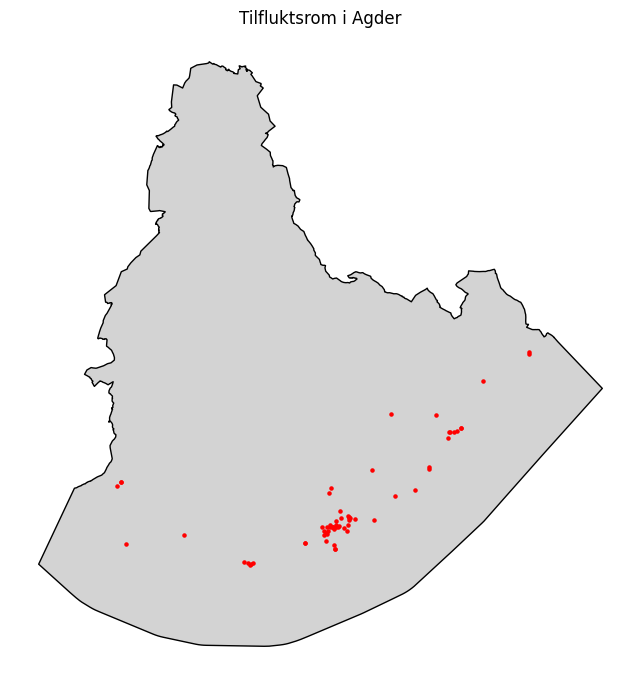

In [10]:
fig, ax = plt.subplots(figsize=(8, 10))

gdf_agder.plot(ax=ax, color="lightgrey", edgecolor="black")
gdf_shelters.plot(ax=ax, color="red", markersize=5)

ax.set_title("Tilfluktsrom i Agder")
ax.set_axis_off()

plt.show()

### 2.8 Innlasting av befolkningsdata

I denne delen lastes befolkningsdata inn i analysen. Datasettet er hentet fra GeoNorge og består av et statistisk rutenett med 250 meters oppløsning for hele Norge.

Hver rute representerer et geografisk område og inneholder tilhørende attributter som kan brukes til å analysere befolkningsfordeling. Dette gir et mer detaljert og presist grunnlag enn administrative enheter som kommuner eller fylker.

Datasettet lagres som en GeoPackage-fil og leses inn ved hjelp av biblioteket GeoPandas. Funksjonen `read_file()` brukes til å importere geografiske data og returnerer en GeoDataFrame, som er en datastruktur som kombinerer tabulære data med geometrisk informasjon.

Etter innlasting vises de første radene av datasettet for å kontrollere at dataene er korrekt lest inn og for å få en oversikt over tilgjengelige variabler.

Det er viktig å merke seg at selv om kun et lite utdrag vises, er hele datasettet lastet inn i minnet. Dette gjør det mulig å utføre videre analyser på hele datagrunnlaget.

In [11]:
import geopandas as gpd

gdf_population = gpd.read_file("../Data/population/population_250m.gpkg")

gdf_population.head()

,OBJECTID,objid,objtype,lokalid,navnerom,versjonid,datauttaksdato,opphav,ssbid250m,SHAPE_Length,SHAPE_Area,geometry
0,1,498311,SSB_Ruter250m,ba70f4fd-7369-48cf-b98b-0034661cd920,https://data.geonorge.no/sosi/befolkning/stati...,20190620,20200706145809,SSB,19000006608250,1000.0,62500.0,"MULTIPOLYGON (((-99750 6608250, -100000 660825..."
1,2,498312,SSB_Ruter250m,dcab378f-bdb0-4b20-af8a-d55f73d23aaf,https://data.geonorge.no/sosi/befolkning/stati...,20190620,20200706145810,SSB,19000006608500,1000.0,62500.0,"MULTIPOLYGON (((-99750 6608500, -100000 660850..."
2,3,498313,SSB_Ruter250m,3605f128-521e-413a-aa50-926c628699b3,https://data.geonorge.no/sosi/befolkning/stati...,20190620,20200706145810,SSB,19000006608750,1000.0,62500.0,"MULTIPOLYGON (((-99750 6608750, -100000 660875..."
3,4,498314,SSB_Ruter250m,ba30fe9e-4c69-47d9-8021-48fd05fe3493,https://data.geonorge.no/sosi/befolkning/stati...,20190620,20200706145810,SSB,19000006609000,1000.0,62500.0,"MULTIPOLYGON (((-99750 6609000, -100000 660900..."
4,5,498315,SSB_Ruter250m,1256ad4a-9905-4f55-b235-32f099944d43,https://data.geonorge.no/sosi/befolkning/stati...,20190620,20200706145810,SSB,19000006609250,1000.0,62500.0,"MULTIPOLYGON (((-99750 6609250, -100000 660925..."


### 2.9 Avgrensning av befolkningsdata til Agder

Befolkningsdatasettet dekker hele Norge og må derfor avgrenses til studieområdet Agder for å gjøre analysen mer relevant og håndterbar.

Før den romlige operasjonen utføres, kontrolleres det at datasettene har samme koordinatsystem (CRS). Romlige operasjoner som clipping forutsetter at geometriene er definert i samme referanseramme, ellers vil resultatene bli feil eller tomme.

Agder-datasettet reprojiseres derfor til samme CRS som befolkningsdataene.

Deretter brukes funksjonen `clip()` fra GeoPandas til å avgrense befolkningsrutenettet til fylkesgrensen for Agder. Clipping innebærer at kun de delene av geometriene som ligger innenfor studieområdet beholdes.

Resultatet er et nytt datasett som kun inneholder befolkningsruter innenfor Agder, og som danner grunnlaget for videre analyser.

In [18]:
# Sørger for at begge datasettene har samme CRS
gdf_agder = gdf_agder.to_crs(gdf_population.crs)

# Klipper befolkningsdata til Agder
gdf_population_agder = gdf_population.clip(gdf_agder)

# Sjekker resultatet
gdf_population_agder.shape

(371005, 12)

# Del 3: Dataklargjøring og koordinatsystemer

Før videre romlige analyser må datasettene klargjøres og kontrolleres.  
Ulike datakilder kan bruke forskjellige koordinatsystemer, geometri-navn og ha varierende datakvalitet.

For at analyser som buffer, overlay og romlig aggregering skal bli korrekte, må alle datasett:

- bruke samme koordinatreferansesystem (CRS)
- ha gyldige og konsistente geometrier

I denne delen:

- kontrolleres datastruktur og geometri-kolonner  
- standardiseres geometri-navn  
- reprojiseres data til et felles CRS  
- ryddes datasettet for videre analyse  

Dette danner grunnlaget for å analysere tilfluktsrommenes dekning i forhold til befolkningen i Agder.

## 3.1 Kontroll av datastruktur

Datasettene kommer fra ulike kilder og kan derfor ha ulike navn på geometri-kolonnen.  
For å unngå feil videre i analysen undersøkes hvilke kolonner som finnes, og hvilken som er aktiv geometri.

In [22]:
print("Kolonner i gdf_agder:", gdf_agder.columns.tolist())
print("Aktiv geometri i gdf_agder:", gdf_agder.geometry.name)

print("\nKolonner i gdf_shelters:", gdf_shelters.columns.tolist())
print("Aktiv geometri i gdf_shelters:", gdf_shelters.geometry.name)

print("\nKolonner i gdf_population_agder:", gdf_population_agder.columns.tolist())
print("Aktiv geometri i gdf_population_agder:", gdf_population_agder.geometry.name)

Kolonner i gdf_agder: ['id', 'navn', 'geomfylke']
Aktiv geometri i gdf_agder: geomfylke

Kolonner i gdf_shelters: ['fid', 'romnr', 'plasser', 'adresse', 'navnerom', 'posisjon']
Aktiv geometri i gdf_shelters: posisjon

Kolonner i gdf_population_agder: ['OBJECTID', 'objid', 'objtype', 'lokalid', 'navnerom', 'versjonid', 'datauttaksdato', 'opphav', 'ssbid250m', 'SHAPE_Length', 'SHAPE_Area', 'geometry']
Akt  iv geometri i gdf_population_agder: geometry


## 3.2 Standardisering av geometri

Geometri-kolonnen har ulike navn i datasettene.  
For å gjøre analysen mer konsistent, standardiseres alle til navnet `geometry`.

In [21]:
gdf_agder = gdf_agder.rename_geometry("geometry")
gdf_shelters = gdf_shelters.rename_geometry("geometry")

print("Agder geometri:", gdf_agder.geometry.name)
print("Shelters geometri:", gdf_shelters.geometry.name)
print("Befolkning geometri:", gdf_population_agder.geometry.name)

Agder geometri: geometry
Shelters geometri: geometry
Befolkning geometri: geometry


## 3.3 Koordinatsystem (CRS)

For å sikre korrekt romlig analyse må alle datasett bruke samme koordinatsystem.  
Data reprojiseres derfor til EPSG:25832 (UTM sone 32N), som egner seg for avstand og areal i Norge.

In [23]:
print("CRS før:")
print("Agder:", gdf_agder.crs)
print("Shelters:", gdf_shelters.crs)
print("Befolkning:", gdf_population_agder.crs)

target_crs = "EPSG:25832"

gdf_agder = gdf_agder.to_crs(target_crs)
gdf_shelters = gdf_shelters.to_crs(target_crs)
gdf_population_agder = gdf_population_agder.to_crs(target_crs)

print("\nCRS etter:")
print("Agder:", gdf_agder.crs)
print("Shelters:", gdf_shelters.crs)
print("Befolkning:", gdf_population_agder.crs)

CRS før:
Agder: EPSG:25832
Shelters: EPSG:25832
Befolkning: EPSG:25832

CRS etter:
Agder: EPSG:25832
Shelters: EPSG:25832
Befolkning: EPSG:25832


I dette tilfellet viser kontrollen at datasettene allerede har samme CRS, og reprojiseringen medfører derfor ingen endring.  
Steget gjennomføres likevel for å sikre og dokumentere et konsistent analysegrunnlag.



## 3.4 Datakvalitet

For å sikre robuste analyser kontrolleres geometriene i datasettene.  
Dette innebærer å sjekke om geometriene er gyldige og om det finnes manglende verdier.

In [28]:
print("Gyldige geometrier:")
print("Agder:", gdf_agder.is_valid.sum(), "/", len(gdf_agder))
print("Shelters:", gdf_shelters.is_valid.sum(), "/", len(gdf_shelters))
print("Befolkning:", gdf_population_agder.is_valid.sum(), "/", len(gdf_population_agder))

Gyldige geometrier:
Agder: 1 / 1
Shelters: 65 / 65
Befolkning: 371005 / 371005


# Del 4: Vektoranalyse

I denne delen gjennomføres romlige analyser for å undersøke forholdet mellom tilfluktsrom og befolkning i Agder.

Målet er å analysere:

- hvor tilfluktsrom er lokalisert  
- hvilke områder av befolkningen som er dekket  
- om det finnes områder med lav eller manglende dekning  

Dette gjøres ved hjelp av vektoranalysemetoder som buffer, overlapp og romlig aggregering.

Analysen bygger på datasettet som er klargjort i Del 3, og gir grunnlag for å vurdere geografisk dekning av tilfluktsrom i forhold til befolkningen.

## 4.1 Buffer rundt tilfluktsrom

For å analysere geografisk dekning opprettes det buffersoner rundt hvert tilfluktsrom.

En buffer er et område rundt et geografisk objekt med en definert avstand.  
I denne analysen brukes buffer for å modellere hvilke områder som ligger innenfor rimelig nærhet til et shelter.

Dette gir et forenklet mål på tilgjengelighet, og gjør det mulig å undersøke hvilke befolkningsområder som faller innenfor eller utenfor dekningssonene i de neste analysestegene.

In [35]:
# Definerer bufferavstand i meter
buffer_distance = 500

# Lager en kopi av shelter-datasettet
gdf_shelters_buffer = gdf_shelters.copy()

# Oppretter buffer rundt hvert shelter
gdf_shelters_buffer["geometry"] = gdf_shelters_buffer.buffer(buffer_distance)

# Skriver ut antall buffere
print("Antall buffersoner:", len(gdf_shelters_buffer))

# Viser de første radene
gdf_shelters_buffer.head()

Antall buffersoner: 65


,fid,romnr,plasser,adresse,navnerom,posisjon,geometry
0,47,1688,136,BANEHEIVEIEN,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (440100.586 6445767.752),"POLYGON ((440600.586 6445767.752, 440598.179 6..."
1,48,1707,195,BYDALSVEIEN 19,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (436546.844 6445699.758),"POLYGON ((437046.844 6445699.758, 437044.437 6..."
2,49,1740,65,FREDRIK FRANSSONSVEI 4,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (446132.066 6449449.801),"POLYGON ((446632.066 6449449.801, 446629.659 6..."
3,50,1755,235,GROSTØLVEIEN 4 E,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (443105.631 6451405.729),"POLYGON ((443605.631 6451405.729, 443603.223 6..."
4,51,1756,500,GRÅGÅSVEIEN 43,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (437355.394 6442727.193),"POLYGON ((437855.394 6442727.193, 437852.986 6..."


For å kontrollere at buffersonene er opprettet korrekt, visualiseres shelterpunktene sammen med bufferområdene. Dette gir en enkel kontroll av hvordan dekningssonene er fordelt i studieområdet.

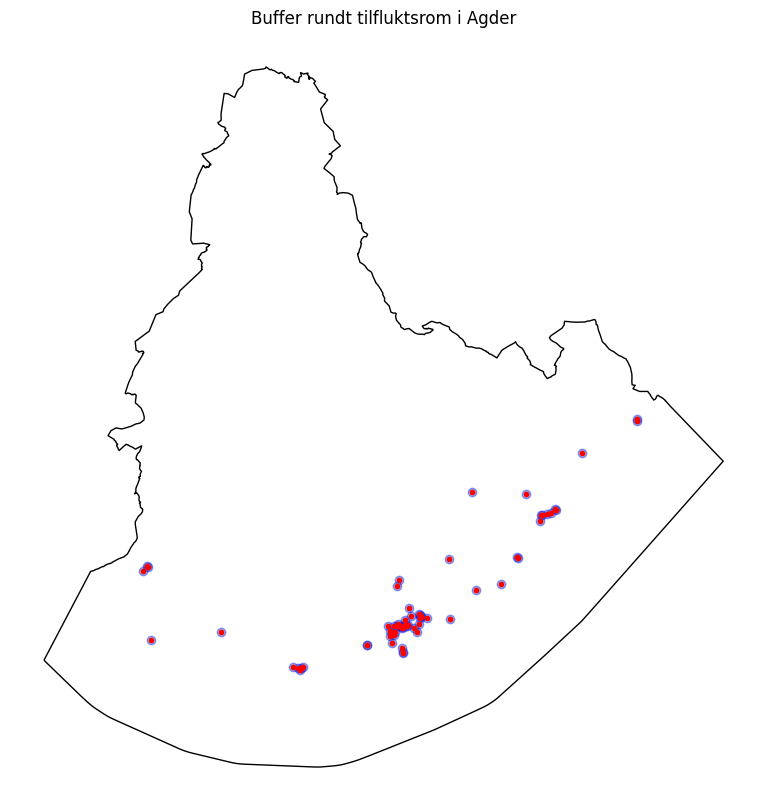

In [36]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_shelters_buffer.plot(ax=ax, alpha=0.4, edgecolor="blue")
gdf_shelters.plot(ax=ax, color="red", markersize=10)
gdf_agder.boundary.plot(ax=ax, color="black", linewidth=1)

ax.set_title("Buffer rundt tilfluktsrom i Agder")
ax.set_axis_off()
plt.show()

For å gjøre buffersonene lettere å tolke vises også et zoomet utsnitt av et område med flere tilfluktsrom.  
Dette gjør det enklere å kontrollere at bufferne er opprettet korrekt og å se hvordan de overlapper.

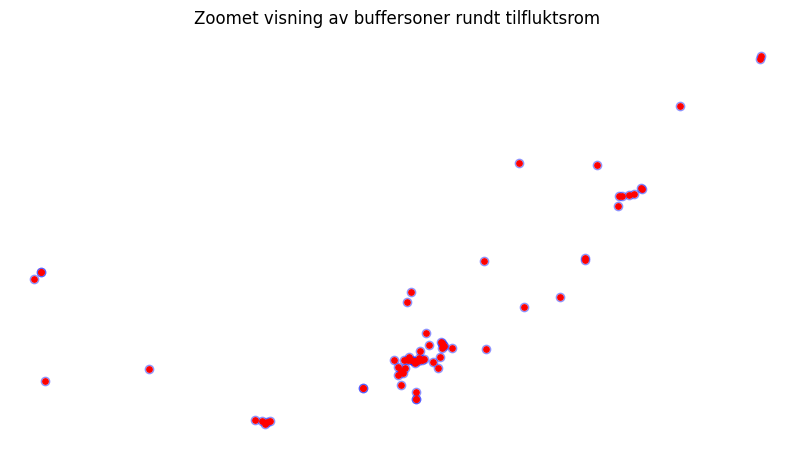

In [38]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_shelters_buffer.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="blue",
    linewidth=1,
    alpha=0.4
)

gdf_shelters.plot(
    ax=ax,
    color="red",
    markersize=15
)

gdf_agder.boundary.plot(
    ax=ax,
    color="white",
    linewidth=1
)

# Zoom inn på område med mange shelters
xmin, ymin, xmax, ymax = gdf_shelters.total_bounds
ax.set_xlim(xmin - 5000, xmax + 5000)
ax.set_ylim(ymin - 5000, ymax + 5000)

ax.set_title("Zoomet visning av buffersoner rundt tilfluktsrom")
ax.set_axis_off()
plt.show()

For å gjøre kartet mer forståelig legges det til et bakgrunnskart.  
Dette gir geografisk kontekst som veier og bebyggelse, og gjør det lettere å tolke buffersonene i forhold til virkeligheten.

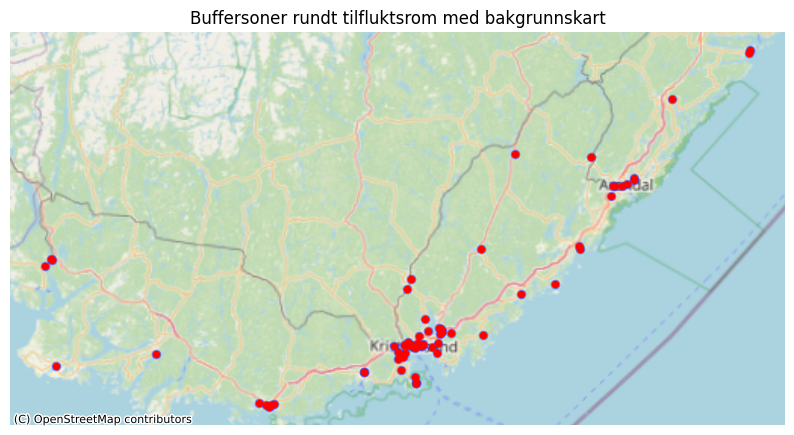

In [45]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))

# Plot buffere
gdf_shelters_buffer.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="blue",
    alpha=0.4
)

# Plot shelterpunkter
gdf_shelters.plot(
    ax=ax,
    color="red",
    markersize=20
)

# Legg til bakgrunnskart
ctx.add_basemap(
    ax,
    crs=gdf_shelters_buffer.crs,
    source=ctx.providers.OpenStreetMap.Mapnik
)

ax.set_title("Buffersoner rundt tilfluktsrom med bakgrunnskart")
ax.set_axis_off()

plt.show()